# Phase 7: Explainable AI (SHAP)

Goal:
Explain why the system flagged specific events as malicious
using feature-level attribution.


In [1]:
import numpy as np
import joblib

X = np.load("../data/X_phase2.npy", allow_pickle=True)
risk_scores = np.load("../data/final_risk_scores.npy", allow_pickle=True)
y = np.load("../data/y_phase2.npy", allow_pickle=True)

iforest = joblib.load("../models/isolation_forest.pkl")

print(X.shape, risk_scores.shape)


(225711, 78) (225701,)


Select High-Risk Alerts Only

In [2]:
TOP_K = 50  # explain top 50 riskiest events

top_idx = np.argsort(risk_scores)[-TOP_K:]
X_explain = X[top_idx]

print("Explaining samples:", X_explain.shape)


Explaining samples: (50, 78)


Initialize SHAP Explainer

In [3]:
import shap

explainer = shap.Explainer(iforest, X)
shap_values = explainer(X_explain)


Global Explanation (System-Wide)

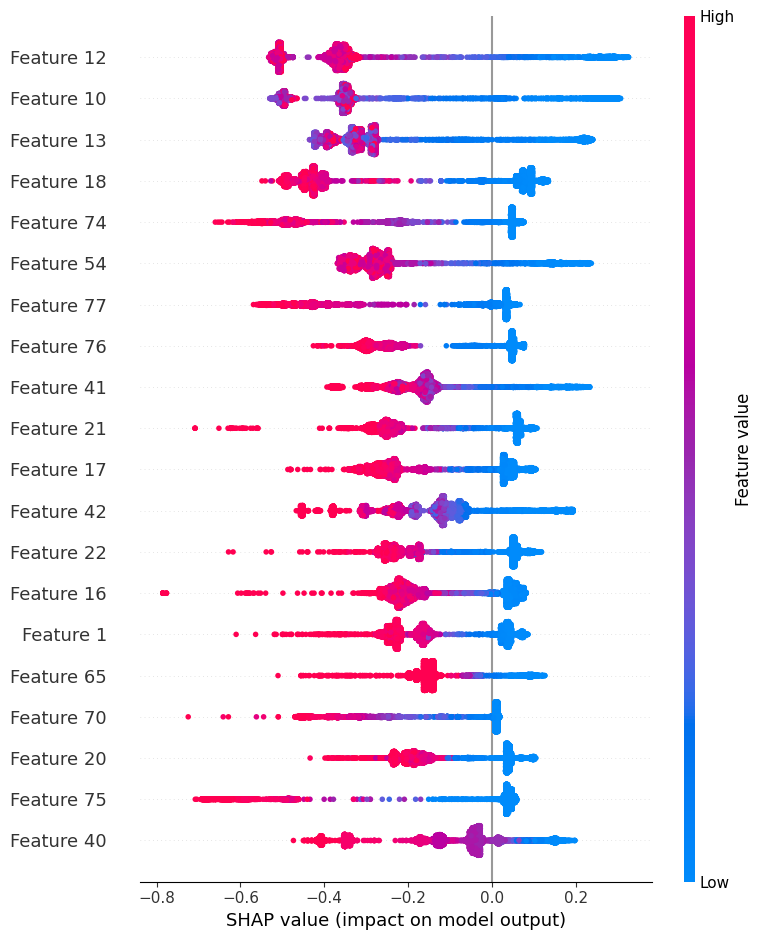

In [16]:
# Use show=False to prevent automatic display
shap.summary_plot(shap_values, show=False)

# Save immediately while the plot is still in memory
import matplotlib.pyplot as plt
plt.savefig("../reports/figures/phase7/global_explanation.png", 
            dpi=300, bbox_inches='tight')
plt.show()  # Now display it

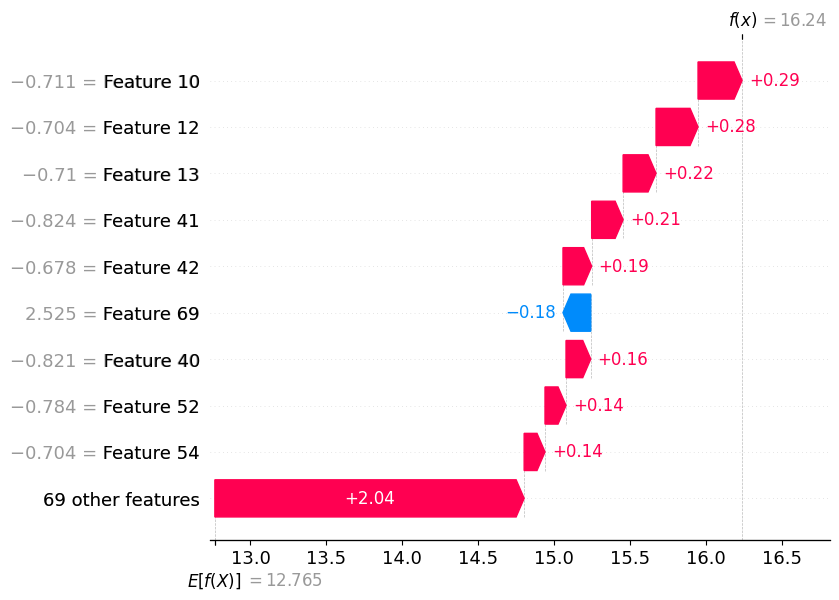

In [ ]:
alert_id = -1  # highest risk alert

# Create the waterfall plot (this will display it)
shap.plots.waterfall(shap_values[alert_id], show=False)

# Immediately save the current figure before showing or closing
import matplotlib.pyplot as plt
plt.savefig("../reports/figures/phase7/shap_waterfall_high_risk.png", 
            dpi=300, bbox_inches='tight')
plt.show()  # Now display it

### Alert Explanation Example

This alert was flagged as HIGH RISK because:
- Flow duration was significantly higher than baseline
- Packet rate deviated sharply from normal behavior
- Unusual byte transfer patterns were observed

These combined deviations strongly indicate anomalous activity
consistent with data exfiltration behavior.


### Explainability Strategy

Instead of using a fixed risk threshold, the system explains the
top-K highest risk alerts. This approach reflects real SOC workflows,
where analysts prioritize the most suspicious events even when
absolute risk thresholds are not exceeded.


optional


In [6]:
np.save("../data/shap_values_high_risk.npy", shap_values.values)
print("SHAP explanations saved")


SHAP explanations saved


## Phase 7 Summary (Saved)

- Applied SHAP to explain anomaly detection decisions
- Generated global and per-alert feature explanations
- Enabled SOC-style reasoning for alerts
- Improved trust and transparency of ML system
- Saved explainability artifacts for dashboard integration


In [7]:
adaptive_threshold = np.percentile(risk_scores, 95)
high_risk_idx = np.where(risk_scores >= adaptive_threshold)[0]


In [8]:
print("Max risk score:", risk_scores.max())
print("Number of high-risk alerts:", len(high_risk_idx))


Max risk score: 0.6889102125999343
Number of high-risk alerts: 11286


In [9]:
HIGH_RISK_PERCENTILE = 95  # top 5% most suspicious events

threshold = np.percentile(risk_scores, HIGH_RISK_PERCENTILE)

high_risk_idx = np.where(risk_scores >= threshold)[0]
X_high_risk = X[high_risk_idx]

print("High-risk threshold:", threshold)
print("High-risk alerts:", X_high_risk.shape)



High-risk threshold: 0.2799480993361623
High-risk alerts: (11286, 78)


In [10]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(iforest, X)
shap_values = explainer(X_high_risk)


100%|===================| 11262/11286 [01:23<00:00]        

In [11]:
import sys
sys.path.append('../src')
from plot_utils import save_plot

shap.summary_plot(shap_values, X_high_risk, show=False)
save_plot("shap_summary.png", phase="phase7")


Plot saved → ../reports/figures/phase7\shap_summary.png
